## 06. 학습 관련 기술들
- 이번 장에서는 가중치 매개변수의 최적값을 탐색하는 최적화 방법, 가중치 매개변수 초깃값, 하이퍼파라미터 설정 방법 등에 대해서 다룸
- 과대 적합(Overfitting)의 대응책인 가중치 감소와 드롭아웃등의 정규화 방법에 대해서도 배우고 구현
- 배치 정규화도 짧게 알아봄

<이전 내용 복습>
입력(넘파이 배열) x -> Affine 계층(np.dot(x, W1) + b1) -> 활성화 함수(sigmoid, ReLU...) -> Affine 계층(np.dot(z, W2) + b2) -> softmax 함수(최종 출력층) -> 손실함수 L 계산 -> 오차역전파로 기울기(grad) 계산 -> 경사하강법으로 가중치 업데이트(W -= lr*grad)

- 오차역전파 = 기울기를 효율적으로 계산하기 위한 방법
- 확률적 경사 하강법(SGD) = 오차역전파에서 구한 기울기로 가중치를 업데이트
---

### 6-1. 매개변수 갱신 
- 신경망 학습의 목적 = 손실 함수의 값을 가능한 낮추는 가중치 매개변수를 찾는 것 = 매개변수의 최적값을 찾는 문제 = 최적화 작업
    - 지금까지는 이 최적화를 위해 매개변수의 기울기(미분)을 이용했고, 이 방법을 확률적 경사 하강법(SGD)라고 부름

#### 6-1-2. 확률적 경사 하강법(SGD)

In [2]:
class SGD:
    def __init__(self, lr = 0.01):
        self.lr = lr

    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]

#### 6-1-3. SGD의 단점
- 아래 그래프와 같은 함수가 있다면, SGD에 의한 최적화 갱신 경로는 **최솟값인(0,0)까지 지그재그로 움직이니 비효율적**
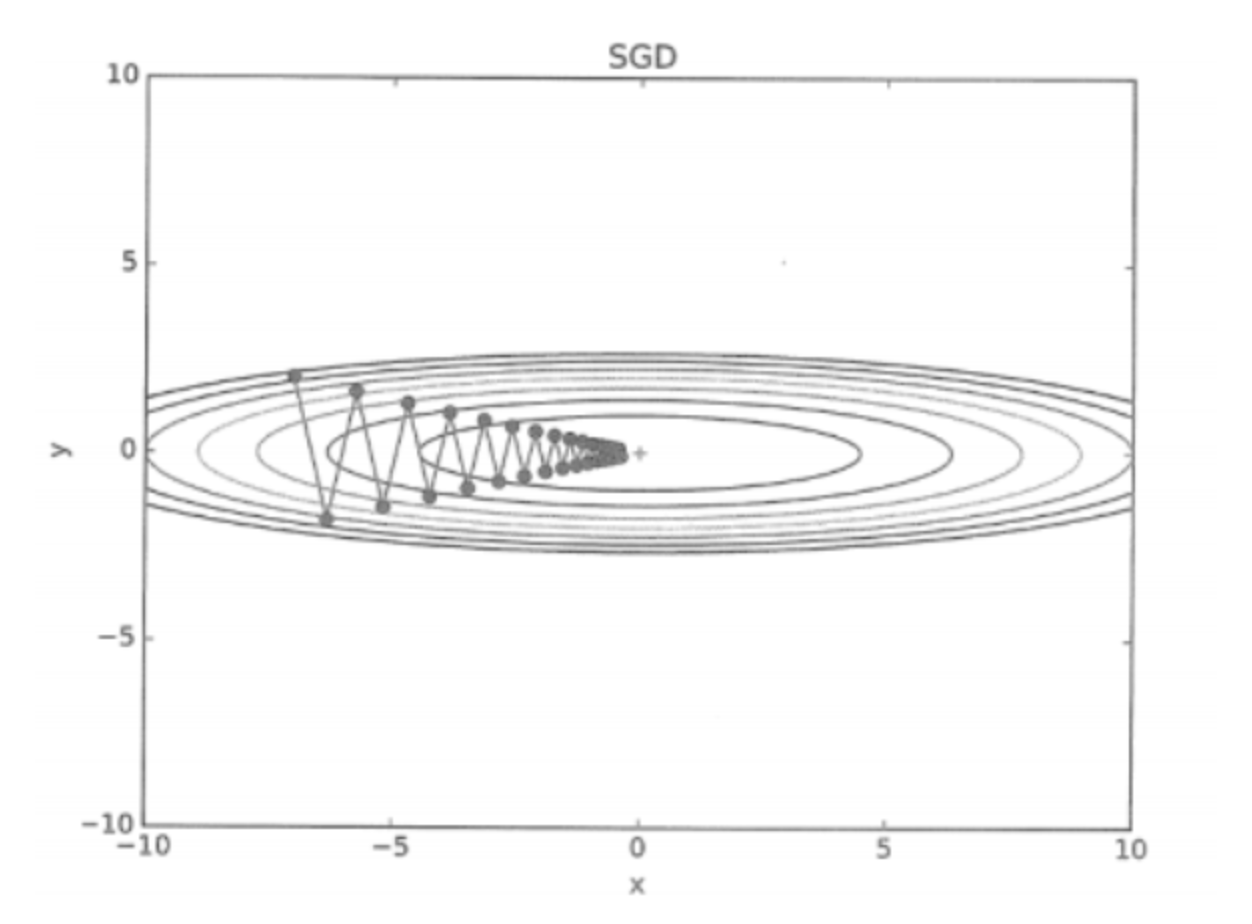

----
그래서,,,
이러한 SGD의 단점(비등방성에서는 탐색 경로가 비효율적임)을 개선해주는 **모멘텀, AdaGrad, Adam**이라는 세 방법이 나옴

#### 6-1-4. 모멘텀(Momentum)
- 운동량을 뜻하는 단어

In [4]:
import numpy as np

class Momentum:
    def __init__(self, lr = 0.01, momentum = 0.9):
        self.lr = lr
        self.momentum = momentum #중력같은 역할. 아무런 힘을 받지 않을 때 서서히 하강시키는 역할
        self.v = None

    #params = {
    #'W1': np.array([[0.1, 0.2], ...]),  
    #'b1': np.array([0.0, 0.0]),
    #'W2': np.array([[0.3, 0.4], ...]),
    #'b2': np.array([0.0, 0.0])
    #}
    def update(self, params, grads):
        if self.v is None:
            self.v = {} 
            for key, val in params.item(): #params = 가중치와 편향이 저장되어있는 딕셔너리 
                self.v[key] = np.zeros_like(val) #'W1' → W1과 같은 shape의 0 배열 / 'b1' → b1과 같은 shape의 0 배열...

        for key in params.keys():
            self.v[key] = self.momentum * self.v[key] - self.lr * grads[key] #grads = 가중치와 편향 기울기
            params[key] += self.v[key]

#### 6-1-5. AdaGrad
- 신경망 학습에는 학습률(learning rate)을 정하는게 가장 중요함
- 학습률을 정하는 효과적인 기술로는 **'학습률 감소'**가 있음
- ✅ **AdaGrad는 '각각의' 매개변수에 '맞춤형' 값을 만들어 줌**
- 아래 AdaGrad 구현 코드에서 주의해야할 점은 📍**마지막 줄에서 1e-7을 더하는 부분 = 0으로 나누는 사태를 막아줌**



In [5]:
class AdaGrad:
    def __init__(self, lr = 0.01):
        self.lr = lr
        self.h = None 

    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)

        for key in params.keys():
            self.h[key] += grads[key] * grads[key]
            params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7)

#### 6-1-6. Adam
- 모멘텀 = 공기 그릇 바닥을 구르는 듯한 움직임을 보임
- AdaGrad = 매개변수의 원소마다 적응적으로 갱신 정도를 조정
- Adam = 모멘텀 + AdaGrad를 결합한 방법 = 하이퍼파라미터의 '편향 보정'이 진행

In [6]:
class Adam:

    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.iter = 0
        self.m = None
        self.v = None
        
    def update(self, params, grads):
        if self.m is None:
            self.m, self.v = {}, {}
            for key, val in params.items():
                self.m[key] = np.zeros_like(val)
                self.v[key] = np.zeros_like(val)
        
        self.iter += 1
        lr_t  = self.lr * np.sqrt(1.0 - self.beta2**self.iter) / (1.0 - self.beta1**self.iter)         
        
        for key in params.keys():
            #self.m[key] = self.beta1*self.m[key] + (1-self.beta1)*grads[key]
            #self.v[key] = self.beta2*self.v[key] + (1-self.beta2)*(grads[key]**2)
            self.m[key] += (1 - self.beta1) * (grads[key] - self.m[key])
            self.v[key] += (1 - self.beta2) * (grads[key]**2 - self.v[key])
            
            params[key] -= lr_t * self.m[key] / (np.sqrt(self.v[key]) + 1e-7)

#### 6-1-7. 어느 갱신 방법을 이용할 것인가?
- 어떤 매개변수의 갱신 방법을 선택하느냐는 풀어야 할 문제가 무엇이냐에 따라 달라짐.
- 주로 SGD와 Adam을 많이 사용함

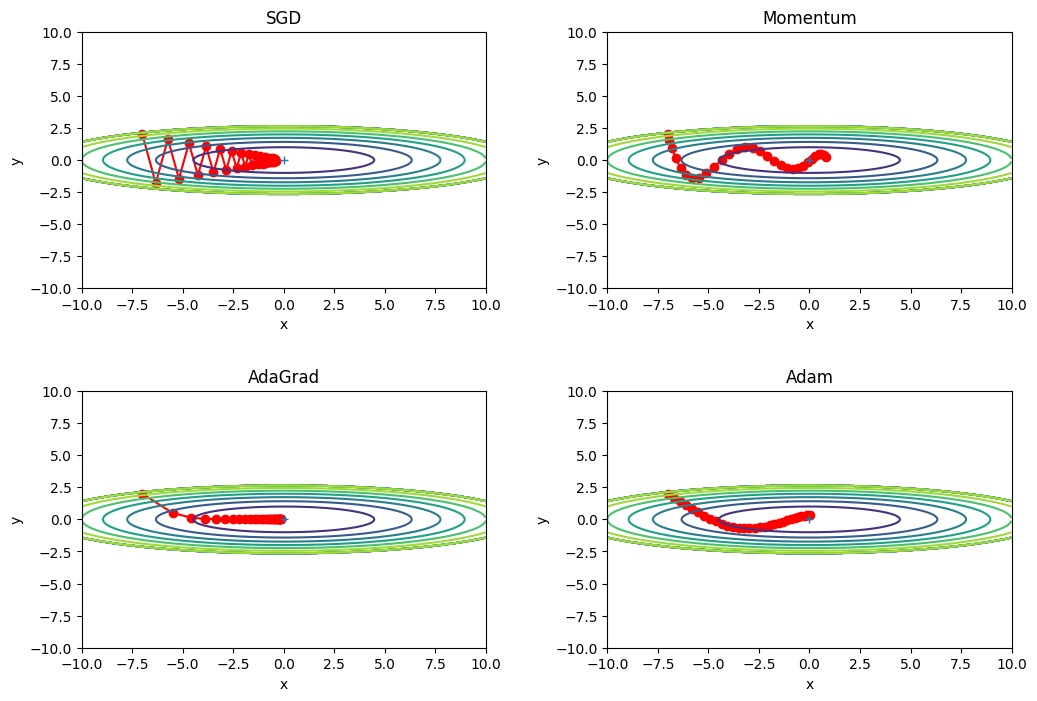

In [7]:
import sys, os

current_dir = os.getcwd() if '__file__' not in locals() else os.path.dirname(__file__)
sys.path.append(os.path.join(current_dir, '..'))

import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from common.optimizer import *


def f(x, y):
    return x**2 / 20.0 + y**2


def df(x, y):
    return x / 10.0, 2.0*y

init_pos = (-7.0, 2.0)
params = {}
params['x'], params['y'] = init_pos[0], init_pos[1]
grads = {}
grads['x'], grads['y'] = 0, 0


optimizers = OrderedDict()
optimizers["SGD"] = SGD(lr=0.95)
optimizers["Momentum"] = Momentum(lr=0.1)
optimizers["AdaGrad"] = AdaGrad(lr=1.5)
optimizers["Adam"] = Adam(lr=0.3)

plt.figure(figsize=(12, 8))

idx = 1

for key in optimizers:
    optimizer = optimizers[key]
    x_history = []
    y_history = []
    params['x'], params['y'] = init_pos[0], init_pos[1]
    
    for i in range(30):
        x_history.append(params['x'])
        y_history.append(params['y'])
        
        grads['x'], grads['y'] = df(params['x'], params['y'])
        optimizer.update(params, grads)
    

    x = np.arange(-10, 10, 0.01)
    y = np.arange(-5, 5, 0.01)
    
    X, Y = np.meshgrid(x, y) 
    Z = f(X, Y)
    
    # 외곽선 단순화
    mask = Z > 7
    Z[mask] = 0
    
    # 그래프 그리기
    plt.subplot(2, 2, idx)
    idx += 1
    plt.plot(x_history, y_history, 'o-', color="red")
    plt.contour(X, Y, Z)
    plt.ylim(-10, 10)
    plt.xlim(-10, 10)
    plt.plot(0, 0, '+')
    plt.title(key)
    plt.xlabel("x")
    plt.ylabel("y")
    
plt.subplots_adjust(wspace=0.3, hspace=0.4)    
plt.show()

#### 6-1-8. MNIST 데이터셋으로 본 갱신 방법 비교
- 손글씨 데이터셋(MNIST 데이터셋)으로 위에서 설명한 네가지 기법(Adam, 모멘텀, AdaGrad, SGD)를 비교해보자
- 각 층이 100개의 뉴런으로 구성된 5층 신경망에서 활성화 함수는 ReLU를 사용하여 측정

---
- 일반적으로는 SGD 보단 다른 세 기법이 빠르게 학습하고, 때로는 최종 정확도도 높게 나타남
- 📍**하지만, 하이퍼파라미터인 학습률과 신경망의 구조(레이어 수, 히든레이어 사이즈 등)에 따라 결과가 달라진다는 것을 항상 인지하고 있어야함.**

===========iteration:0===========
SGD:2.4183074457843396
Momentum:2.4032432443791207
AdaGrad:2.208875348247794
Adam:2.1856645759042372
===========iteration:100===========
SGD:1.530681048215156
Momentum:0.3845868667487949
AdaGrad:0.16970428910127328
Adam:0.25956375952293237
===========iteration:200===========
SGD:0.7807819842565614
Momentum:0.2430852821284179
AdaGrad:0.15439724058112386
Adam:0.17286704010475995
===========iteration:300===========
SGD:0.5367810667952582
Momentum:0.21800165832489232
AdaGrad:0.06732701624806614
Adam:0.14161057375987443
===========iteration:400===========
SGD:0.44550040199824903
Momentum:0.25508124342449323
AdaGrad:0.09013552067874026
Adam:0.1402369175265067
===========iteration:500===========
SGD:0.44171555161961285
Momentum:0.12438115297865257
AdaGrad:0.08388794205585895
Adam:0.09158511972122543
===========iteration:600===========
SGD:0.363536793629889
Momentum:0.12563691849321384
AdaGrad:0.06460453331852944
Adam:0.11688443792893444
===========iteration:7

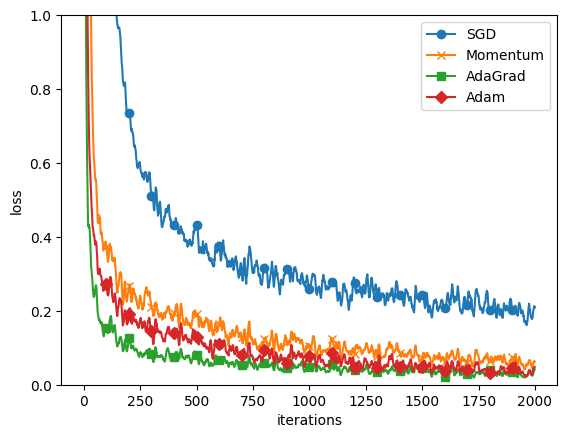

In [8]:
import sys, os

current_dir = os.getcwd() if '__file__' not in locals() else os.path.dirname(__file__)
sys.path.append(os.path.join(current_dir, '..'))

import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.util import smooth_curve
from common.multi_layer_net import MultiLayerNet
from common.optimizer import *


# 0. MNIST 데이터 읽기==========
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


# 1. 실험용 설정==========
optimizers = {}
optimizers['SGD'] = SGD()
optimizers['Momentum'] = Momentum()
optimizers['AdaGrad'] = AdaGrad()
optimizers['Adam'] = Adam()
#optimizers['RMSprop'] = RMSprop()

networks = {}
train_loss = {}
for key in optimizers.keys():
    networks[key] = MultiLayerNet(
        input_size=784, hidden_size_list=[100, 100, 100, 100],
        output_size=10)
    train_loss[key] = []    


# 2. 훈련 시작==========
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    for key in optimizers.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizers[key].update(networks[key].params, grads)
    
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    
    if i % 100 == 0:
        print( "===========" + "iteration:" + str(i) + "===========")
        for key in optimizers.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


# 3. 그래프 그리기==========
markers = {"SGD": "o", "Momentum": "x", "AdaGrad": "s", "Adam": "D"}
x = np.arange(max_iterations)
for key in optimizers.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 1)
plt.legend()
plt.show()

### 6-2. 가중치의 초깃값
- 신경망 학습에서는 가중치의 초깃값이 특히 중요함
- 권장 초깃값에 대해서 설명하고 실험을 통해 신경망 학습이 이뤄지는 모습을 확인

#### 6-2-1. 초깃값을 0으로 하면?
- 가중치의 초깃값 = 0.01 * np.random.randn(10,100)으로 설정
    - 초깃값을 이렇게 랜덤으로 설정하지 않고 모두 동일한 값으로 설정하면, 오차역전파법에서 갱신된 값들이 다 동일하기 때문에 학습이 이뤄지지 않음

#### 6-2-2. 은닉층의 활성화값 분포
- 가중치의 초깃값에 따라 은닉층 활성화값들이 어떻게 변화하는지 실험해볼 것.
- 활성화 함수로 시그모이드 함수를 사용하는 5층 신경망에 무작위로 생성한 입력 데이터를 흘리며 각 층의 활성화값 분포를 히스토그램으로 시각화

#### 가중치를 다르게 해서 실험해보기
1. w = np.random.randn(node_num, node_num) * 1 인  경우 
- 활성화 값들이 0과 1에 치우쳐서 분포 -> 역전파의 기울기들이 점점 작아지다가 사라짐
2. w = np.random.randn(node_num, node_num) * 0.01
- 0.5부근에 집중됨, 소실 문제는 일어나지 않지만 값이 치우쳤다는 뜻이기 때문에 다양한 학습을 못하게 됨
- 활성화 값들이 치우치면 표현력을 제한한다는 문제가 있음
3. w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)
- 활성화 값들이 넓게 퍼져서 분포함. 표현력 제한도 없고 학습이 기울기 소실도 없으며 학습이 효율적으로 이루어짐


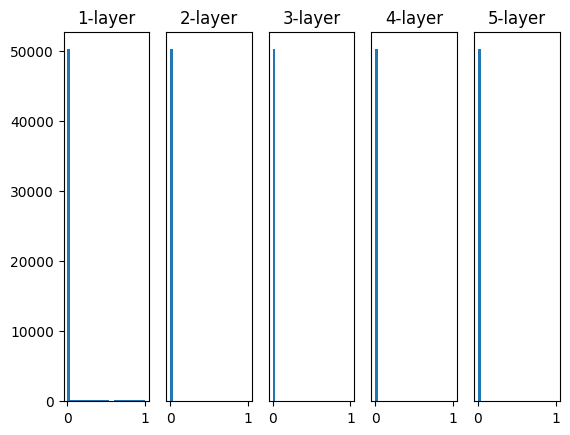

In [5]:
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def ReLU(x):
    return np.maximum(0, x)


def tanh(x):
    return np.tanh(x)
    
input_data = np.random.randn(1000, 100)  # 1000개의 데이터
node_num = 100  # 각 은닉층의 노드(뉴런) 수
hidden_layer_size = 5  # 은닉층이 5개
activations = {}  # 이곳에 활성화 결과를 저장

x = input_data

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

    # ⭐️초깃값을 다양하게 바꿔가며 실험
    w = np.random.randn(node_num, node_num) * 1
    # w = np.random.randn(node_num, node_num) * 0.01
    # w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)
    # w = np.random.randn(node_num, node_num) * np.sqrt(2.0 / node_num)


    a = np.dot(x, w)


    # 활성화 함수도 바꿔가며 실험
    # z = sigmoid(a)
    z = ReLU(a)
    # z = tanh(a)

    activations[i] = z

# 히스토그램 그리기
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0: plt.yticks([], [])
    # plt.xlim(0.1, 1)
    # plt.ylim(0, 7000)
    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()

===========iteration:0===========
std=0.01:2.3025550091378104
Xavier:2.3039934965222697
He:2.417708510689276
===========iteration:100===========
std=0.01:2.302777098420425
Xavier:2.24216551821494
He:1.5480327099832283
===========iteration:200===========
std=0.01:2.302041504371525
Xavier:2.128208014430255
He:0.7895446672658915
===========iteration:300===========
std=0.01:2.3003913418438584
Xavier:1.7813064374605538
He:0.5233242672592705
===========iteration:400===========
std=0.01:2.299240404683262
Xavier:1.3540877189117126
He:0.49035306826975733
===========iteration:500===========
std=0.01:2.30287843543059
Xavier:0.900259651090227
He:0.42625977869081266
===========iteration:600===========
std=0.01:2.306337540293134
Xavier:0.68661954381026
He:0.38517062206728264
===========iteration:700===========
std=0.01:2.3017507589547352
Xavier:0.5909710217211137
He:0.3642001713501801
===========iteration:800===========
std=0.01:2.300540259909714
Xavier:0.4412342259989973
He:0.28284524172048464
====

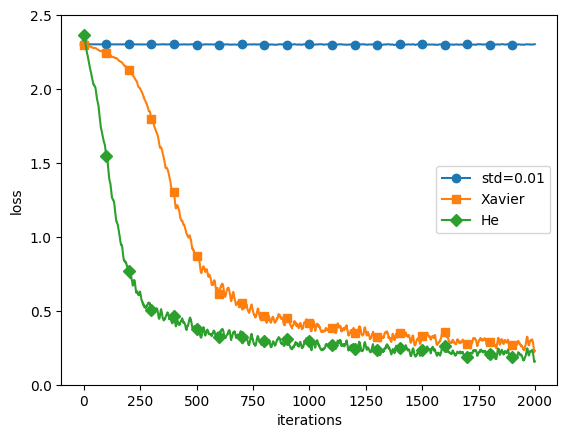

In [6]:
import sys, os

current_dir = os.getcwd() if '__file__' not in locals() else os.path.dirname(__file__)
sys.path.append(os.path.join(current_dir, '..'))

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.util import smooth_curve
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD


# 0. MNIST 데이터 읽기==========
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


# 1. 실험용 설정==========
weight_init_types = {'std=0.01': 0.01, 'Xavier': 'sigmoid', 'He': 'relu'}
optimizer = SGD(lr=0.01)

networks = {}
train_loss = {}
for key, weight_type in weight_init_types.items():
    networks[key] = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100],
                                  output_size=10, weight_init_std=weight_type)
    train_loss[key] = []


# 2. 훈련 시작==========
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    for key in weight_init_types.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizer.update(networks[key].params, grads)
    
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    
    if i % 100 == 0:
        print("===========" + "iteration:" + str(i) + "===========")
        for key in weight_init_types.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


# 3. 그래프 그리기==========
markers = {'std=0.01': 'o', 'Xavier': 's', 'He': 'D'}
x = np.arange(max_iterations)
for key in weight_init_types.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 2.5)
plt.legend()
plt.show()

### 6-3. 배치 정규화 
이전까지는 가중치의 초기값을 절절히 설정하면 각 층의 활성화값 분포가 적당히 퍼지면서 학습이 원활하게 진행
✅ **각 층이 활성화를 적당히 퍼뜨리도록 '강제'하는 아이디어에서 출발한 것 = '배치 정규화'**

#### 6-3-1. 배치 정규화 알고리즘
- 배치 정규화의 장점
    - 학습을 빨리 진행할 수 있음
    - 초깃값에 크게 의존하지 않음
    - 과대적합을 억제함

- **배치 정규화 = 학습 시 미니배치를 단위로 정규화하는 것**
    - 미니배치 B = {$x_1$, $x_2$, $x_3$, $x_4$...$x_m$}이라는 m개의 입력 데이터의 집합에 대해 평균과 분선을 구하고, 입력 데이터를 평균이 0, 분산이 1이 되도록 정규화하는 것 

epoch:0 | 0.068 - 0.149
epoch:1 | 0.077 - 0.176
epoch:2 | 0.088 - 0.301
epoch:3 | 0.093 - 0.438
epoch:4 | 0.104 - 0.516
epoch:5 | 0.115 - 0.581
epoch:6 | 0.122 - 0.619
epoch:7 | 0.142 - 0.662
epoch:8 | 0.151 - 0.711
epoch:9 | 0.155 - 0.752
epoch:10 | 0.172 - 0.784
epoch:11 | 0.166 - 0.808
epoch:12 | 0.167 - 0.829
epoch:13 | 0.169 - 0.845
epoch:14 | 0.193 - 0.865
epoch:15 | 0.206 - 0.869
epoch:16 | 0.23 - 0.885
epoch:17 | 0.228 - 0.888
epoch:18 | 0.248 - 0.893
epoch:19 | 0.278 - 0.904


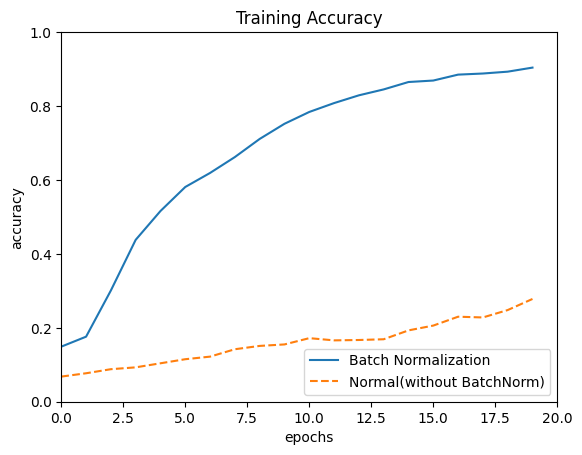

In [7]:
import sys, os

current_dir = os.getcwd() if '__file__' not in locals() else os.path.dirname(__file__)
sys.path.append(os.path.join(current_dir, '..'))

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.optimizer import SGD, Adam

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 학습 데이터를 줄임
x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 20
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.01


def __train(weight_init_std):
    bn_network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10, 
                                    weight_init_std=weight_init_std, use_batchnorm=True)
    network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)
    
    train_acc_list = []
    bn_train_acc_list = []
    
    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0
    
    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]
    
        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)
    
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            bn_train_acc = bn_network.accuracy(x_train, t_train)
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)
    
            print("epoch:" + str(epoch_cnt) + " | " + str(train_acc) + " - " + str(bn_train_acc))
    
            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break
                
    return train_acc_list, bn_train_acc_list


# 그래프 그리기==========
weight_scale_list = np.logspace(0, -4, num=16)
x = np.arange(max_epochs)

train_acc_list, bn_train_acc_list = __train(weight_scale_list[4])
    
plt.title("Training Accuracy")
plt.plot(x, bn_train_acc_list, label='Batch Normalization', markevery=2)
plt.plot(x, train_acc_list, linestyle = "--", label='Normal(without BatchNorm)', markevery=2)
plt.ylim(0, 1.0)
plt.xlim(0, max_epochs)
plt.ylabel("accuracy")
plt.xlabel("epochs")
plt.legend(loc='lower right')
    
plt.show()

============== 1/16 ==============
epoch:0 | 0.105 - 0.067
epoch:1 | 0.094 - 0.079
epoch:2 | 0.092 - 0.125
epoch:3 | 0.093 - 0.142


/Users/songga0ee/Desktop/HOME/deep_learning/vol1-basic/../common/multi_layer_net_extend.py:105: RuntimeWarning: overflow encountered in square
  weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2)
/Users/songga0ee/Desktop/HOME/deep_learning/vol1-basic/../common/multi_layer_net_extend.py:105: RuntimeWarning: invalid value encountered in scalar multiply
  weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2)


epoch:4 | 0.1 - 0.155
epoch:5 | 0.116 - 0.178
epoch:6 | 0.116 - 0.195
epoch:7 | 0.116 - 0.21
epoch:8 | 0.116 - 0.231
epoch:9 | 0.117 - 0.25
epoch:10 | 0.116 - 0.269
epoch:11 | 0.116 - 0.29
epoch:12 | 0.117 - 0.306
epoch:13 | 0.116 - 0.317
epoch:14 | 0.116 - 0.339
epoch:15 | 0.116 - 0.354
epoch:16 | 0.116 - 0.368
epoch:17 | 0.116 - 0.387
epoch:18 | 0.116 - 0.4
epoch:19 | 0.117 - 0.412
============== 2/16 ==============
epoch:0 | 0.099 - 0.092
epoch:1 | 0.097 - 0.098
epoch:2 | 0.097 - 0.136
epoch:3 | 0.097 - 0.169
epoch:4 | 0.097 - 0.184
epoch:5 | 0.097 - 0.205
epoch:6 | 0.097 - 0.225
epoch:7 | 0.097 - 0.244
epoch:8 | 0.097 - 0.264
epoch:9 | 0.097 - 0.287
epoch:10 | 0.097 - 0.312
epoch:11 | 0.097 - 0.331
epoch:12 | 0.097 - 0.355
epoch:13 | 0.097 - 0.368
epoch:14 | 0.097 - 0.394
epoch:15 | 0.097 - 0.425
epoch:16 | 0.097 - 0.43
epoch:17 | 0.097 - 0.452
epoch:18 | 0.097 - 0.47
epoch:19 | 0.097 - 0.481
============== 3/16 ==============
epoch:0 | 0.144 - 0.094
epoch:1 | 0.383 - 0.116
epoch:2

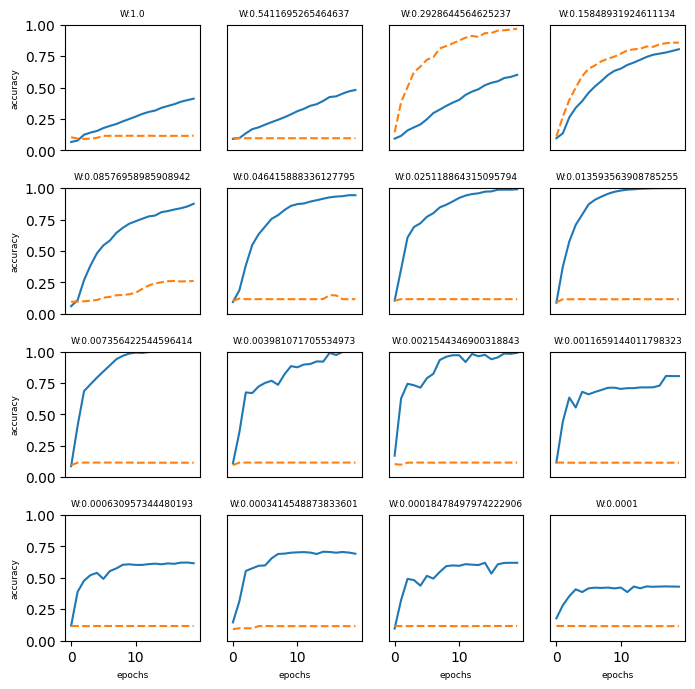

In [8]:
import sys, os

current_dir = os.getcwd() if '__file__' not in locals() else os.path.dirname(__file__)
sys.path.append(os.path.join(current_dir, '..'))

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.optimizer import SGD, Adam

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 학습 데이터를 줄임
x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 20
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.01


def __train(weight_init_std):
    bn_network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10, 
                                    weight_init_std=weight_init_std, use_batchnorm=True)
    network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)
    
    train_acc_list = []
    bn_train_acc_list = []
    
    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0
    
    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]
    
        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)
    
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            bn_train_acc = bn_network.accuracy(x_train, t_train)
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)
    
            print("epoch:" + str(epoch_cnt) + " | " + str(train_acc) + " - " + str(bn_train_acc))
    
            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break
                
    return train_acc_list, bn_train_acc_list


# 그래프 그리기==========
weight_scale_list = np.logspace(0, -4, num=16)
x = np.arange(max_epochs)

plt.figure(figsize=(8, 8))

for i, w in enumerate(weight_scale_list):
    print( "============== " + str(i+1) + "/16" + " ==============")
    train_acc_list, bn_train_acc_list = __train(w)
    
    plt.subplot(4,4,i+1)
    plt.title("W:" + str(w), fontsize=6.5)
    plt.plot(x, bn_train_acc_list, markevery=2)
    plt.plot(x, train_acc_list, linestyle="--", markevery=2)

    plt.ylim(0, 1.0)
    if i % 4:
        plt.yticks([])
    else:
        plt.ylabel("accuracy", fontsize=6.5)
    if i < 12:
        plt.xticks([])
    else:
        plt.xlabel("epochs", fontsize=6.5)
    
plt.subplots_adjust(wspace=0.2, hspace=0.3)    
plt.show()

### 6-4. 바른 학습을 위해
- **과대적합**이 문제가 되는 경우가 많음
    - 신경망이 훈련 데이터에만 지나치게 적응되어 그 외의 데이터에는 제대로 대응하지 못하는 상태

#### 6-4-1. 과대적합
- 과대 적합이 일어나는 경우
    - 매개변수가 많고, 표현력이 높은 모델 
    - 훈련 데이터가 적은 모델 -> 아래 코드와 같은 경우
        - 결과 : 훈련 데이터셋과 테스트 데이터셋에서의 정확도가 크게 벌어짐(train은 높고, test는 낮음)

- 과대적합 방지를 위한 솔루션은 **가중치 감소(6-4-2) 와 드롭아웃(6-4-3)**이 있음

epoch:0, train acc:0.1, test acc:0.0991
epoch:1, train acc:0.12333333333333334, test acc:0.1129
epoch:2, train acc:0.15, test acc:0.1272
epoch:3, train acc:0.16333333333333333, test acc:0.1488
epoch:4, train acc:0.21333333333333335, test acc:0.1719
epoch:5, train acc:0.24333333333333335, test acc:0.1921
epoch:6, train acc:0.2833333333333333, test acc:0.2128
epoch:7, train acc:0.31666666666666665, test acc:0.2265
epoch:8, train acc:0.3566666666666667, test acc:0.2513
epoch:9, train acc:0.38, test acc:0.2688
epoch:10, train acc:0.43333333333333335, test acc:0.2811
epoch:11, train acc:0.48, test acc:0.3118
epoch:12, train acc:0.51, test acc:0.3339
epoch:13, train acc:0.5366666666666666, test acc:0.36
epoch:14, train acc:0.58, test acc:0.3888
epoch:15, train acc:0.6066666666666667, test acc:0.4118
epoch:16, train acc:0.61, test acc:0.4161
epoch:17, train acc:0.64, test acc:0.4368
epoch:18, train acc:0.6633333333333333, test acc:0.4621
epoch:19, train acc:0.68, test acc:0.4851
epoch:20, tra

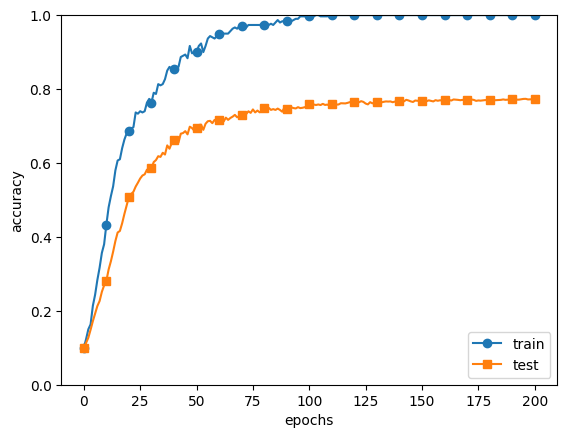

In [10]:
import sys, os

current_dir = os.getcwd() if '__file__' not in locals() else os.path.dirname(__file__)
sys.path.append(os.path.join(current_dir, '..'))

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 과대적합을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10)
optimizer = SGD(lr=0.01)  # 학습률이 0.01인 SGD로 매개변수 갱신

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


# 그래프 그리기==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

#### 6-4-2. 가중치 감소


epoch:0, train acc:0.13333333333333333, test acc:0.1272
epoch:1, train acc:0.15, test acc:0.1312
epoch:2, train acc:0.16, test acc:0.1357
epoch:3, train acc:0.18333333333333332, test acc:0.1437
epoch:4, train acc:0.22666666666666666, test acc:0.1517
epoch:5, train acc:0.25333333333333335, test acc:0.1644
epoch:6, train acc:0.2833333333333333, test acc:0.1812
epoch:7, train acc:0.29333333333333333, test acc:0.1944
epoch:8, train acc:0.29, test acc:0.2034
epoch:9, train acc:0.31333333333333335, test acc:0.2229
epoch:10, train acc:0.33, test acc:0.2367
epoch:11, train acc:0.3333333333333333, test acc:0.2506
epoch:12, train acc:0.3333333333333333, test acc:0.264
epoch:13, train acc:0.36, test acc:0.281
epoch:14, train acc:0.39, test acc:0.2986
epoch:15, train acc:0.42333333333333334, test acc:0.3124
epoch:16, train acc:0.42333333333333334, test acc:0.3202
epoch:17, train acc:0.4266666666666667, test acc:0.3192
epoch:18, train acc:0.43333333333333335, test acc:0.3255
epoch:19, train acc:0.4

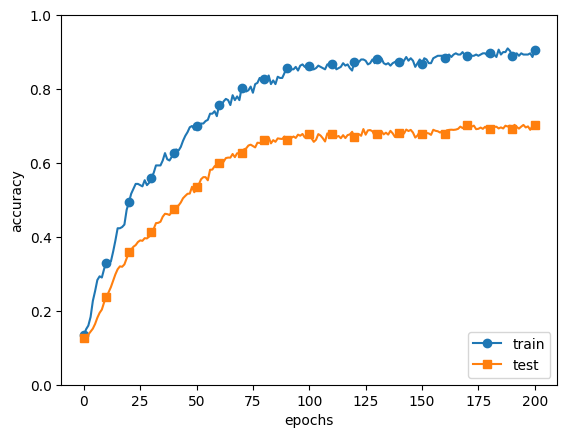

In [11]:
import sys, os

current_dir = os.getcwd() if '__file__' not in locals() else os.path.dirname(__file__)
sys.path.append(os.path.join(current_dir, '..'))

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 과대적합을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

weight_decay_lambda = 0.1 # 가중치 감쇠 설정

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=weight_decay_lambda)
optimizer = SGD(lr=0.01) # 학습률이 0.01인 SGD로 매개변수 갱신

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


# 그래프 그리기==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

#### 6-4-3. 드롭 아웃
📍가중치 감소의 경우 신경망 모델이 복잡해지면 대응이 어려움
✅ 이런 경우, 뉴런을 임의로 삭제하며 학습시키는 **'드롭 아웃'**을 사용함
- 훈련 때는 은닉층의 뉴런을 무작위로 골라서 삭제하여 데이터를 흘릴 때마다 삭제할 뉴런을 무작위로 선택함
- 테스트 때는 모든 뉴런에 신호를 전달

In [12]:
class Dropout:
    def __init__(self, dropout_ratio=0.5):
        self.dropout_ratio = dropout_ratio
        self.mask = None

    def forward(self, x, train_flg = True):
        if train_flg:
            self.mask = np.random.rand(*x.shape) > self.dropout_ratio
            return x * self.mask
        
        else:
            return x * (1.0 - self.dropout_ratio)
        
    def backward(self, dout):
        return dout * self.mask

train loss:2.305250293531009
=== epoch:1, train acc:0.09, test acc:0.0935 ===
train loss:2.295980950919892
train loss:2.3111066282292114
train loss:2.3187170114524567
=== epoch:2, train acc:0.09666666666666666, test acc:0.0935 ===
train loss:2.306880686618949
train loss:2.2989813105940797
train loss:2.3112930693109446
=== epoch:3, train acc:0.09666666666666666, test acc:0.0943 ===
train loss:2.3119561332465084
train loss:2.316052857819208
train loss:2.3088679251884674
=== epoch:4, train acc:0.1, test acc:0.0948 ===
train loss:2.3064419183352087
train loss:2.305520840978581
train loss:2.3024542169176874
=== epoch:5, train acc:0.1, test acc:0.0945 ===
train loss:2.2926960573755157
train loss:2.311746917981405
train loss:2.2979740861393667
=== epoch:6, train acc:0.09666666666666666, test acc:0.0952 ===
train loss:2.291915970197835
train loss:2.309598229140378
train loss:2.3052525509383655
=== epoch:7, train acc:0.09333333333333334, test acc:0.0952 ===
train loss:2.305795468364861
train lo

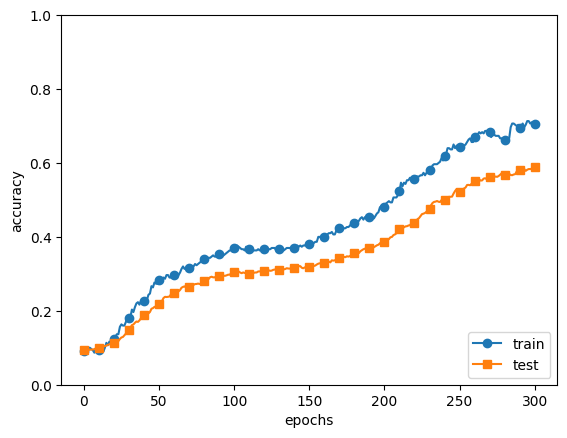

In [13]:
import sys, os

current_dir = os.getcwd() if '__file__' not in locals() else os.path.dirname(__file__)
sys.path.append(os.path.join(current_dir, '..'))

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.trainer import Trainer

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 오버피팅을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

# 드롭아웃 사용 유무와 비율 설정 ========================
use_dropout = True  # 드롭아웃을 쓰지 않을 때는 False
dropout_ratio = 0.2
# ====================================================

network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                              output_size=10, use_dropout=use_dropout, dropout_ration=dropout_ratio)
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=301, mini_batch_size=100,
                  optimizer='sgd', optimizer_param={'lr': 0.01}, verbose=True)
trainer.train()

train_acc_list, test_acc_list = trainer.train_acc_list, trainer.test_acc_list

# 그래프 그리기==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

### 6-5. 적절한 하이퍼파라미터 값 찾기
- 하이퍼파라미터 = 각 층의 뉴런 수, 배치 크기, 매개변수 갱신 시의 학습률과 가중치 감소 등...

#### 6-5-1. 검증 데이터
- 하이퍼파라미터 값을 다양한 값으로 설정하고 검증 시에는 **하이퍼파라미터 전용 데이터인 '검증 데이터'를 사용함**

---
즉,,,
훈련 데이터 = 매개변수 학습

검증 데이터 = 하이퍼파라미터 성능 평가

테스트 데이터 = 신경망의 범용 성능을 평가

In [ ]:
(x_train, t_train), (x_test, t_test) = load_mnist()

x_train, t_train = shuffle_dataset(x_train, t_train)

validation_rate = 0.2
validation_num = int(x_train.shape[0] * validation_rate)

x_val = x_train[:validation_num]
t_val = t_train[:validation_num]
x_train = x_train[validation_num:]
t_train = t_train[validation_num:]